# Study 1: Economic Growth (GDP) vs. CO₂ Emissions

This analysis explores the relationship between **GDP per capita** and **CO₂ emissions per capita** across different countries. We investigate if economic growth correlates with environmental impact.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from modules.data_loader import DataLoader


## Load Preprocessed Data
We load 4 databases and merge into a single DataFrame with the following columns:
 `Continent`, `Country`, `year`, `co2`, `gdp`, `population`, `total_co2`, `total_gdp`

In [3]:
# Load the preprocessed CSV 
loader = DataLoader()            # Create an instance of the DataLoader class
data = loader.load_and_prepare_data()  # Call the method to load and clean the data
data.head()

,Continent,Country,year,co2,gdp,population,total_co2,total_gdp
0,Africa,Algeria,1800,0.0,763.0,2500000.0,0.0,1.907500e+09
1,Africa,Algeria,1801,0.0,764.0,2510000.0,0.0,1.917640e+09
2,Africa,Algeria,1802,0.0,765.0,2520000.0,0.0,1.927800e+09
3,Africa,Algeria,1803,0.0,766.0,2530000.0,0.0,1.937980e+09
4,Africa,Algeria,1804,0.0,767.0,2540000.0,0.0,1.948180e+09


## Scatter Plot: GDP vs CO₂ per Capita (2020)
Visualizing the correlation between GDP per capita and CO₂ emissions for the year 2020.

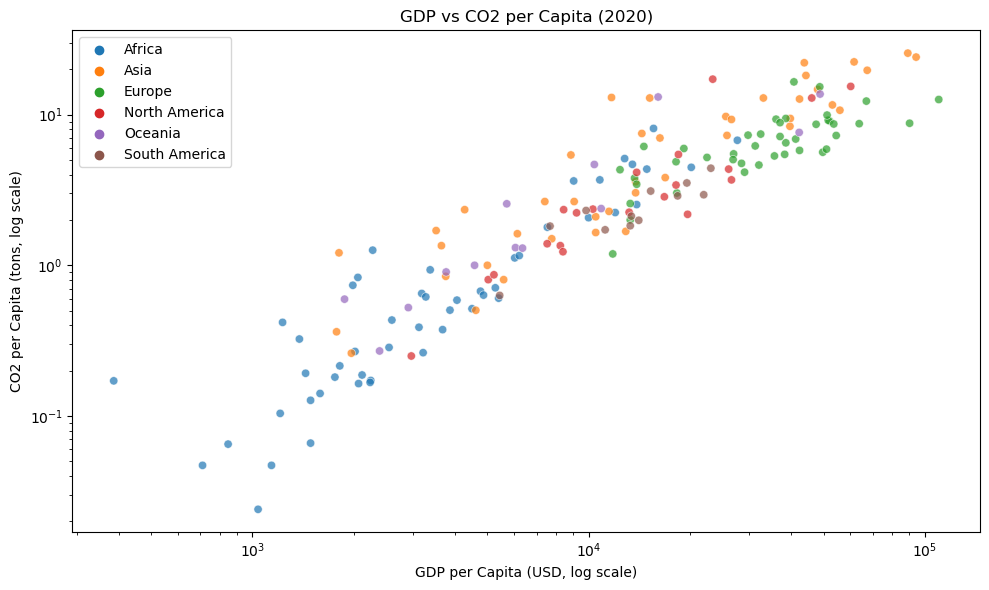

In [4]:
year_filter = 2020
scatter_data = data[data["year"] == year_filter]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_data, x="gdp", y="co2", hue="Continent", alpha=0.7)
plt.xscale("log")
plt.yscale("log")
plt.title(f"GDP vs CO2 per Capita ({year_filter})")
plt.xlabel("GDP per Capita (USD, log scale)")
plt.ylabel("CO2 per Capita (tons, log scale)")
plt.legend()
plt.tight_layout()
plt.show()

There is a **strong positive correlation** between **GDP per capita** and **CO₂ emissions per capita**.

Generally, richer countries emit more CO₂ per person.

We look at top 15 countries with highest CO2 emissions: 

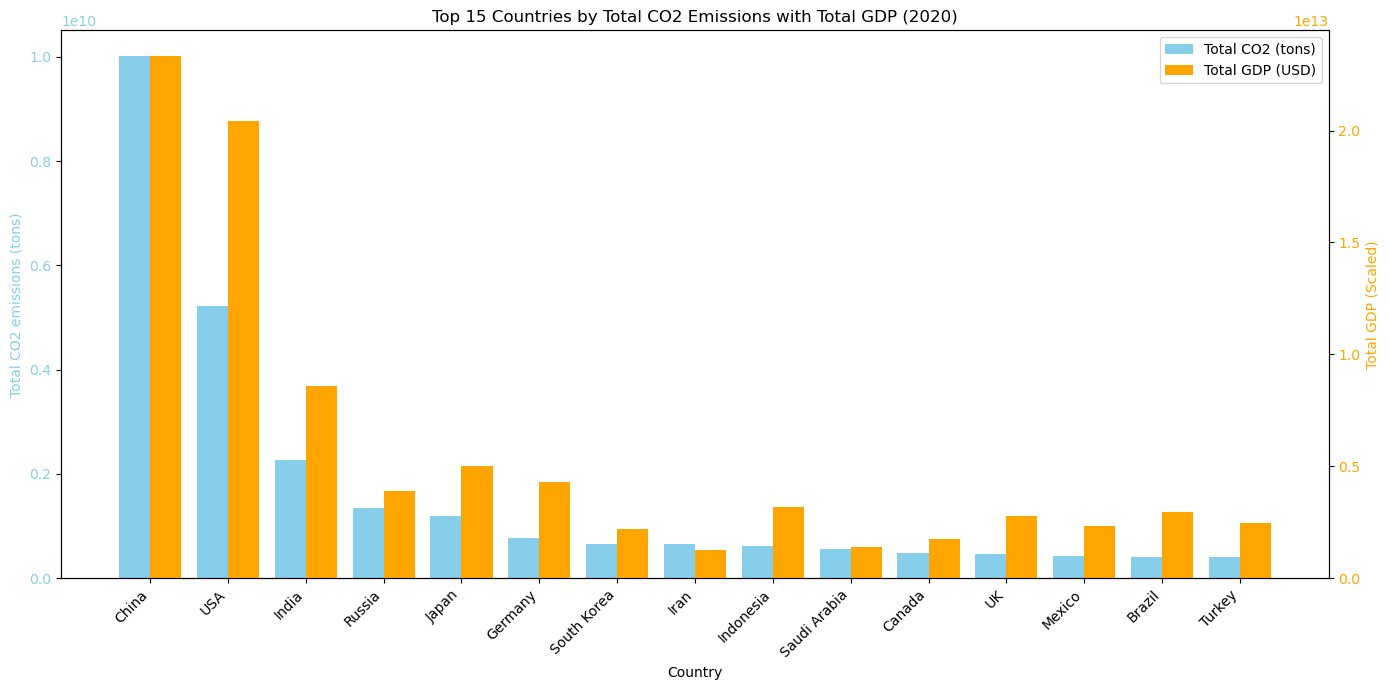

In [12]:
# Filter for the year 2020
data_2020 = data[data['year'] == 2020].copy()

# Drop missing values
data_2020 = data_2020.dropna(subset=['total_co2', 'gdp'])

# Get top 15 countries by total CO2
top_15 = data_2020.sort_values(by='total_co2', ascending=False).head(15)

# Sort by CO2 for consistent display
top_15 = top_15.sort_values(by='total_co2', ascending=False)

# Extract values
countries = top_15['Country']
co2_values = top_15['total_co2']
gdp_values = top_15['total_gdp'] 

# Bar settings
x = np.arange(len(countries))  # Label locations
width = 0.4  # Width of the bars

# Create plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar for CO2 on primary y-axis
bars1 = ax1.bar(x - width/2, co2_values, width, label='Total CO2 (tons)', color='skyblue')
ax1.set_xlabel('Country')
ax1.set_ylabel('Total CO2 emissions (tons)', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Create secondary y-axis for GDP
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, gdp_values, width, label='Total GDP (USD)', color='orange')
ax2.set_ylabel('Total GDP (Scaled)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Title and x-ticks
ax1.set_title('Top 15 Countries by Total CO2 Emissions with Total GDP (2020)')
ax1.set_xticks(x)
ax1.set_xticklabels(countries, rotation=45, ha='right')

# Legends
# Combine legends from both axes
bars = [bars1, bars2]
labels = [bar.get_label() for bar in bars]
ax1.legend(bars, labels, loc='upper right')

plt.tight_layout()
plt.show()


1. China leads CO₂ emissions by far

    China’s total CO₂ emissions are significantly higher than any other country—more than twice that of the USA.

    However, its total GDP is lower than the USA, indicating a high emissions-to-GDP ratio.

2. USA: High CO₂ and highest GDP

    The USA has the second-highest total CO₂ emissions, but the USA leads in total GDP.

    This implies a relatively lower CO₂ intensity per GDP compared to countries like China and India.

3. India, Russia and Iran: High CO₂ with relatively low GDP

    India is 3rd in CO₂ emissions, but its total GDP is noticeably lower than top economic powers.

4. Germany and Japan: lower emissions and highest GDP

    Japan and Germany show high GDPs but moderate CO₂ emissions.

5. South Korea, Canada, UK: Emissions efficiency varies

    These countries show comparable GDP levels with modest emissions—indicating better emissions efficiency.

    Canada shows lower total emissions.

6. Developing countries: High CO₂ and modest GDP

    Indonesia, Brazil, Mexico, and Turkey show modest GDP but significant CO₂ contributions.

  

## Trend Over Time for Selected Countries
We examine GDP and CO₂ trends for countries with highest emissions.

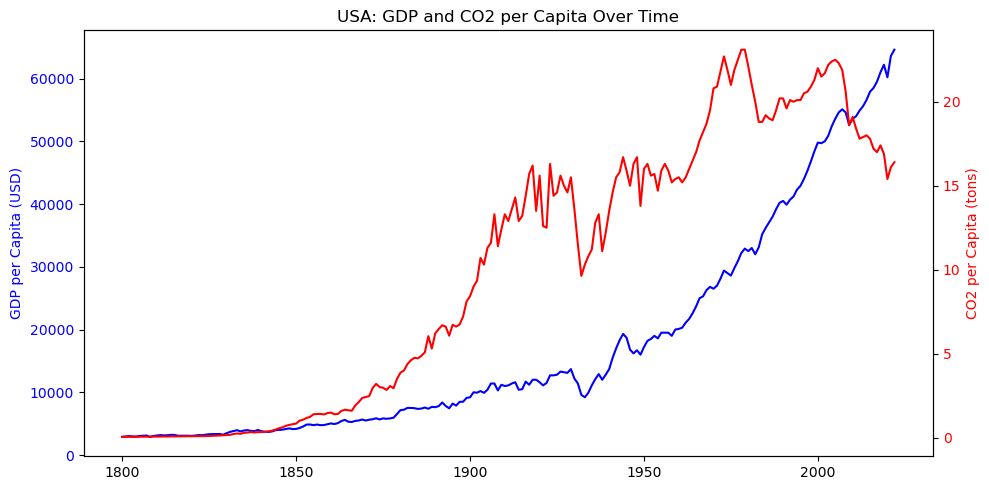

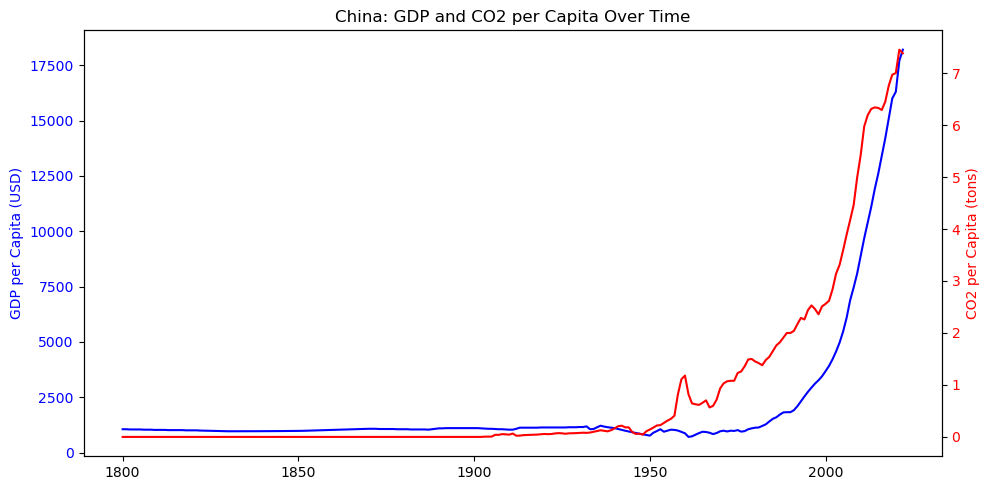

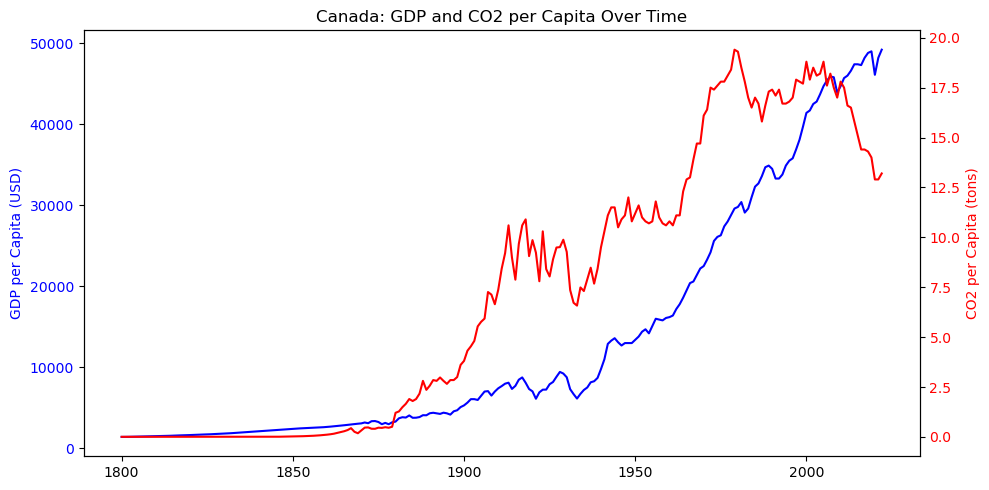

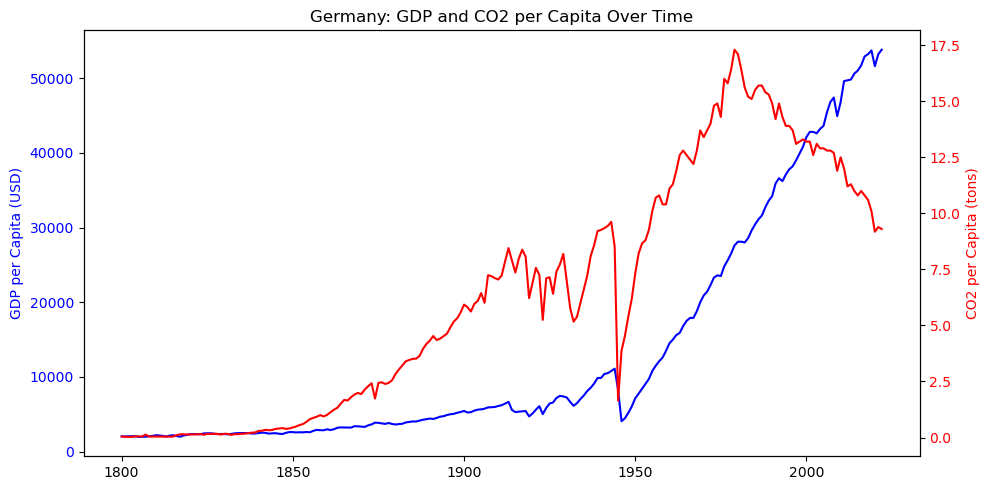

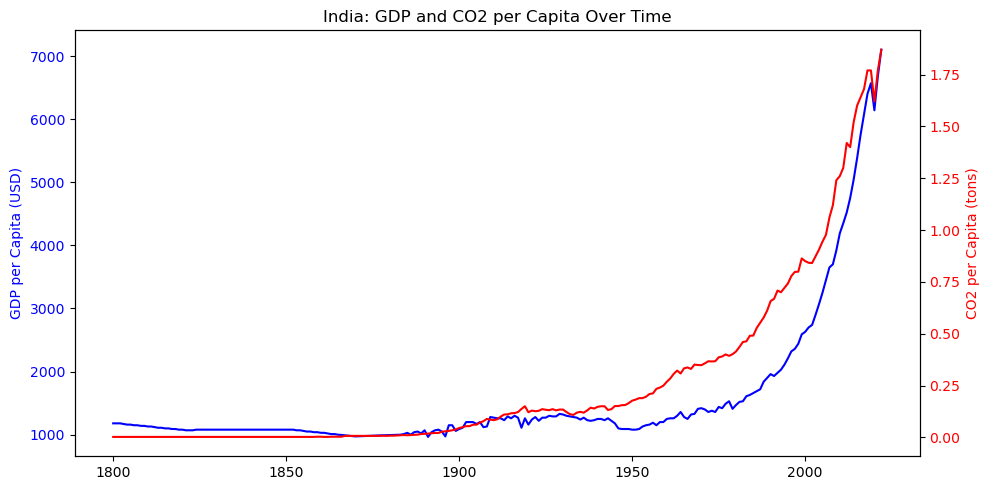

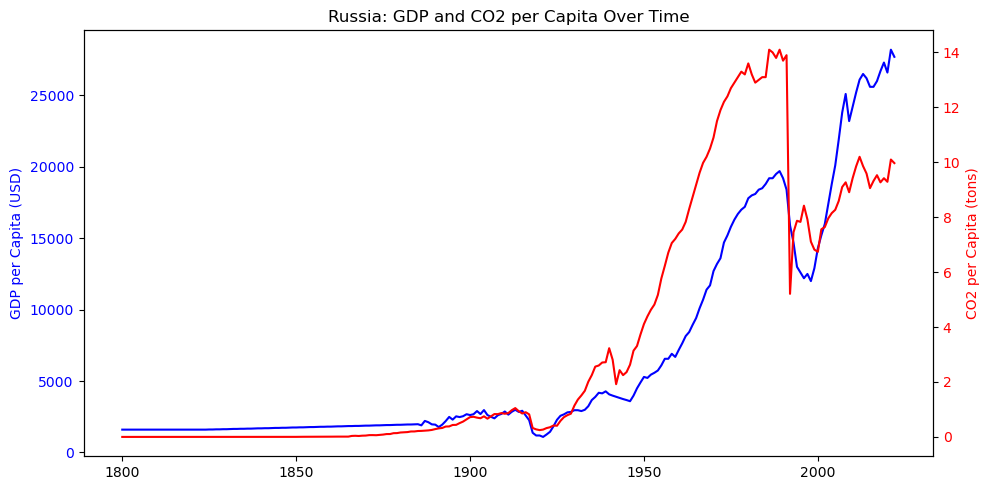

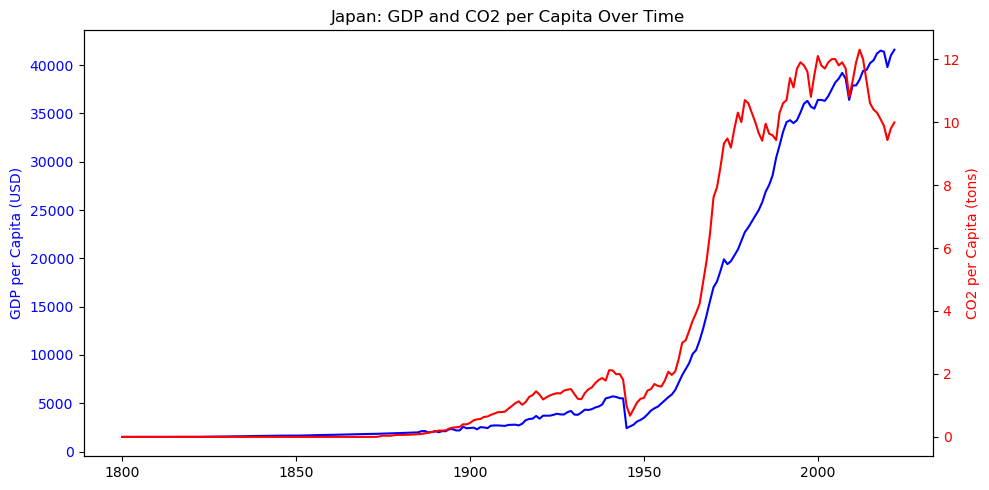

In [13]:
selected_countries = ["USA", "China", "Canada", "Germany", "India", "Russia", "Japan"]

for country in selected_countries:
    cData = data[data["Country"] == country].sort_values("year")
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.set_title(f"{country}: GDP and CO2 per Capita Over Time")
    ax1.plot(cData["year"], cData["gdp"], color="blue", label="GDP per Capita")
    ax1.set_ylabel("GDP per Capita (USD)", color="blue")
    ax1.tick_params(axis='y', labelcolor="blue")

    ax2 = ax1.twinx()
    ax2.plot(cData["year"], cData["co2"], color="red", label="CO2 per Capita")
    ax2.set_ylabel("CO2 per Capita (tons)", color="red")
    ax2.tick_params(axis='y', labelcolor="red")

    plt.tight_layout()
    plt.show()

## Correlation Analysis
Compute Pearson correlation between GDP and CO₂ per capita.

c:\Users\Behzad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Behzad\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


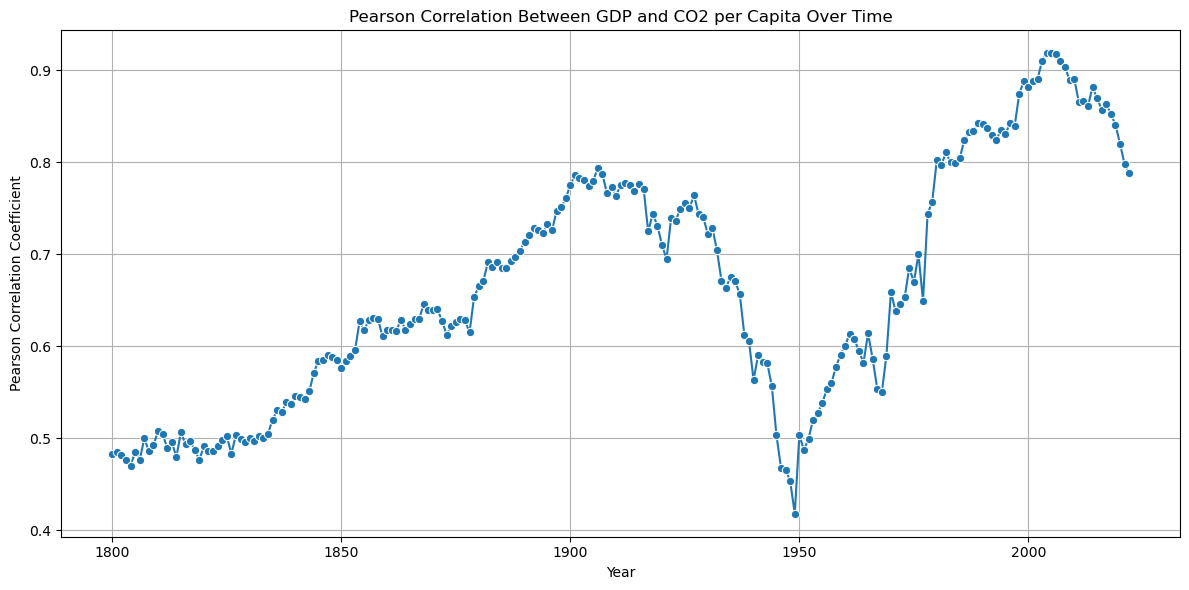

In [7]:
pd.option_context('mode.use_inf_as_na', True)
# Calculate Pearson correlation between GDP and CO₂ per capita for each year
correlation_by_year = data.groupby("year").apply(
    lambda group: group["gdp"].corr(group["co2"])
).reset_index(name="pearson_correlation")

# Plot the correlation trend over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=correlation_by_year, x="year", y="pearson_correlation", marker="o")
plt.title("Pearson Correlation Between GDP and CO2 per Capita Over Time")
plt.xlabel("Year")
plt.ylabel("Pearson Correlation Coefficient")
plt.grid(True)
plt.tight_layout()
plt.show()

This graph shows a complex and evolving relationship between economic development and carbon emissions:

**1- Early Industrialization (1800 - ~1900):** This century saw a consistent and strong increase in the correlation, indicating that economic growth became progressively more tied to rising CO2 emissions per capita.

**2- Mid-20th Century Volatility and Recovery (~1900 - ~1970s):** Following an initial peak, the correlation sharply declined during periods of global disruption before recovering strongly, re-establishing a robust positive link between GDP and CO2 per capita.

**3- Late 20th Century Strong Correlation (~1970s - Early 2000s):** The correlation reached its highest point, showing a strong and direct relationship between GDP per capita and CO2 per capita.

**4- Early 21st Century Decoupling Trend (Early 2000s - Present):** After its peak, the correlation shows a noticeable decline, suggesting a potential decoupling where economic growth per capita is becoming less directly tied to increases in CO2 per capita. This could be due to many reasons including:

    Increased energy efficiency.
    Shifts in economic structure towards less carbon-intensive industries 
    Adoption of renewable energy sources in some parts of the world.
    Improved environmental regulations and policies.